In [1]:
%%capture
# We require gensim package later on, but it seems it is built with numpy==1.x
# whereas Colab has numpy>=2.x. We downgrade numpy to 1.x.

!pip install numpy
!pip install --force-reinstall --no-deps pandas scipy

# RESTART YOUR SESSION NOW (ONLY FOR COLAB/KAGGLE)

In [3]:
from IPython.core.interactiveshell import InteractiveShell
InteractiveShell.ast_node_interactivity = "all"

In [8]:
%%capture
!curl -s "https://get.sdkman.io" | bash && source "$HOME/.sdkman/bin/sdkman-init.sh" && sdk install java 11.0.22-amzn < /dev/null

In [9]:
%%capture
!pip install python-terrier
!pip install gensim

In [40]:
!pip show gensim

Name: gensim
Version: 4.4.0
Summary: Python framework for fast Vector Space Modelling
Home-page: https://radimrehurek.com/gensim/
Author: Radim Rehurek
Author-email: me@radimrehurek.com
License: LGPL-2.1-only
Location: /usr/local/lib/python3.12/dist-packages
Requires: numpy, scipy, smart_open
Required-by: 


In [38]:
!pip show numpy

Name: numpy
Version: 2.0.2
Summary: Fundamental package for array computing in Python
Home-page: https://numpy.org
Author: Travis E. Oliphant et al.
Author-email: 
License: Copyright (c) 2005-2024, NumPy Developers.
All rights reserved.

Redistribution and use in source and binary forms, with or without
modification, are permitted provided that the following conditions are
met:

    * Redistributions of source code must retain the above copyright
       notice, this list of conditions and the following disclaimer.

    * Redistributions in binary form must reproduce the above
       copyright notice, this list of conditions and the following
       disclaimer in the documentation and/or other materials provided
       with the distribution.

    * Neither the name of the NumPy Developers nor the names of any
       contributors may be used to endorse or promote products derived
       from this software without specific prior written permission.

THIS SOFTWARE IS PROVIDED BY THE COPYRI

# SE 2025 - Lab 4: Query Expansion

Today, we will see how to run approaches based on language models and query rewriting in PyTerrier.

In [10]:
import gensim
import numpy as np
import pandas as pd
import warnings
import os
from pprint import pprint
from pyterrier.measures import *
from tqdm.auto import tqdm

warnings.filterwarnings("ignore", category=FutureWarning)

In [12]:
!ls -lah /usr/lib/jvm
!find /usr/lib/jvm -name libjvm.so

total 16K
drwxr-xr-x 3 root root 4.0K May  6 13:11 .
drwxr-xr-x 1 root root 4.0K May  6 13:11 ..
lrwxrwxrwx 1 root root   21 Jan 29 03:35 java-1.17.0-openjdk-amd64 -> java-17-openjdk-amd64
-rw-r--r-- 1 root root 1.8K Jan 29 03:35 .java-1.17.0-openjdk-amd64.jinfo
drwxr-xr-x 9 root root 4.0K May  6 13:11 java-17-openjdk-amd64
/usr/lib/jvm/java-17-openjdk-amd64/lib/server/libjvm.so


In [11]:
import os

# Force Java 17
os.environ["JAVA_HOME"] = "/usr/lib/jvm/java-17-openjdk-amd64"
os.environ["JVM_PATH"] = "/usr/lib/jvm/java-17-openjdk-amd64/lib/server/libjvm.so"

os.environ["PATH"] = os.environ["JAVA_HOME"] + "/bin:" + os.environ["PATH"]
os.environ["LD_LIBRARY_PATH"] = (
    os.environ["JAVA_HOME"] + "/lib/server:"
    + os.environ.get("LD_LIBRARY_PATH", "")
)

print("JAVA_HOME:", os.environ["JAVA_HOME"])
print("JVM_PATH:", os.environ["JVM_PATH"])

!java -version
!ls -lah $JAVA_HOME/lib/server/libjvm.so

JAVA_HOME: /usr/lib/jvm/java-17-openjdk-amd64
JVM_PATH: /usr/lib/jvm/java-17-openjdk-amd64/lib/server/libjvm.so
openjdk version "17.0.18" 2026-01-20
OpenJDK Runtime Environment (build 17.0.18+8-Ubuntu-122.04.1)
OpenJDK 64-Bit Server VM (build 17.0.18+8-Ubuntu-122.04.1, mixed mode, sharing)
-rw-r--r-- 1 root root 24M Jan 29 03:35 /usr/lib/jvm/java-17-openjdk-amd64/lib/server/libjvm.so


## Systems Setup

We will start by building an index of our data collection and a few systems in PyTerrier.
This step is only required to obtain system outputs.

In [12]:
base = 'https://raw.githubusercontent.com/Legenden84/search-engines/master/lab_test'

docs = pd.read_csv(f'{base}/lab_docs.csv', dtype={'docno': str, 'text': str})
topics = pd.read_csv(f'{base}/lab_topics.csv', dtype={'qid': str})
qrels = pd.read_csv(f'{base}/lab_qrels.csv', dtype={'qid': str, 'docno': str, 'label': int})

In [13]:
# Build index
indexer = pt.IterDictIndexer("./indexes/pt_index_default", overwrite=True, blocks=True)
index_ref = indexer.index(docs.to_dict(orient='records'))
index = pt.IndexFactory.of(index_ref)
print(index.getCollectionStatistics().toString())

NameError: name 'pt' is not defined

In [20]:
# Build SEs
TF = pt.terrier.Retriever(index, wmodel="Tf")
TF_IDF = pt.terrier.Retriever(index, wmodel="TF_IDF")
BM25 = pt.terrier.Retriever(index, wmodel="BM25")

In [21]:
# Evaluate systems on the topics using the PyTerrier Experiment interface
pt.Experiment(
    retr_systems=[TF, TF_IDF, BM25],
    names=['TF', 'TF-IDF', 'BM25'],
    topics=topics,
    qrels=qrels,
    eval_metrics=[AP@10, nDCG@10, P@10],
    round=4
)

,name,P@10,nDCG@10,AP@10
0,TF,0.8000,0.8510,0.3375
1,TF-IDF,0.7667,0.8408,0.3429
2,BM25,0.7667,0.8425,0.3455


## Pipelines

Before looking at query rewriting techniques, we will have a look at PyTerrier pipelines, which will be used in the rest of this notebook.

Part of the power of PyTerrier comes indeed from having these pipelines, that allow to easily formulate complex retrieval pipelines.
Particularly relevant to us, today, is the chaining pipeline, which is obtained with the `>>` (Then) operator.
This operator allows us to perform multiple steps one after the other.

For example, as we will see later in the course, a typical approach consists of re-ranking documents that were first retrieved by another system.
Given a query $Q$ and two ranking systems $\text{R}_1$ and $\text{R}_2$, we can perform the following pipeline:
$$ R' = \text{R}_2(\text{R}_1(Q)))$$
through the `>>` operator:
$$\text{Pipeline} = R_1 >> R_2$$
$$R' = \text{Pipeline}(Q)$$
where $R'$ is the list of ranked documents.

In the following, we will be adding query expansion as an intermediate step between re-ranking in order to perform ranking with pseudo-relevance feedback.

## Query Rewriting

Query rewriting consists of reformulating the original query in order to improve the effectiveness of a ranking system.
The basic idea behind this technique is to return relevant documents even if there is no term that matches with the original query, hence possibly increasing the quality of the ranking.

Although queries can be rewritten by users, in this notebook, we will look at automatic techniques to query rewriting.
In particular, PyTerrier differentiates between two forms of query rewriting:

- Query expansion `Q -> Q`: this rewrites a query $Q$, for instance by adding/removing extra query terms.

- Pseudo-relevance feedback `R -> Q`: this rewrites a query $Q$ by making use of an associated set of documents $R$.


### Query Expansion

PyTerrier offers native access to Metzler and Croft’s sequential dependence model (`sdm`), designed to boost the scores of documents where the query terms occur in close proximity.
This technique rewrites each input query such that:
- pairs of adjacent query terms are added as #1 and #uw8 complex query terms, with a low weight
- the full query is added as #uw12 complex query term, with a low weight.
- all terms are weighted by a proximity model, such as the Dirichlet LM

For example, the query **pyterrier IR platform** would become **pyterrier IR platform #1(pyterrier IR) #1(IR platform) #uw8(pyterrier IR) #uw8(IR platform) #uw12(pyterrier IR platform)**.

In some ways, this is similar to n-grams in language modeling, the difference being that #uw8(pyterrier IR) implies looking for 'pyterrier' and 'IR' co-occuring -- in any order -- in window of 8 tokens.

In [22]:
# First, expand queries through the sequential dependence model
# Then, use BM25 to rank the documents in the collection using the expanded queries
SDM = pt.rewrite.SequentialDependence()
SDM_BM25 = SDM >> BM25

We can look at how the query ""black wall" is expanded by SDM as follows:

In [23]:
SDM_BM25.search("black wall").head(2)

,qid,docid,docno,rank,score,query,query_0
0,1,1357,1221197,0,14.597648,black wall #combine:0=0.1:wmodel=org.terrier.m...,black wall
1,1,203,1455841,1,12.188280,black wall #combine:0=0.1:wmodel=org.terrier.m...,black wall


In [24]:
SDM_BM25.search("black wall").iloc[0]['query']

'black wall #combine:0=0.1:wmodel=org.terrier.matching.models.dependence.pBiL(#1(black wall)) #combine:0=0.1:wmodel=org.terrier.matching.models.dependence.pBiL(#uw8(black wall)) #combine:0=0.1:wmodel=org.terrier.matching.models.dependence.pBiL(#uw12(black wall))'

In [25]:
SDM_BM25.search("black wall").iloc[0]["query_0"]

'black wall'

In [26]:
pt.Experiment(
    retr_systems=[TF, TF_IDF, BM25, SDM_BM25],
    names=['TF', 'TF-IDF', 'BM25', 'SDM >> BM25'],
    topics=topics,
    qrels=qrels,
    eval_metrics=[AP@10, nDCG@10, P@10],
    round=4
)

,name,P@10,nDCG@10,AP@10
0,TF,0.8000,0.8510,0.3375
1,TF-IDF,0.7667,0.8408,0.3429
2,BM25,0.7667,0.8425,0.3455
3,SDM >> BM25,0.7667,0.8425,0.3455


#### Query Expansion with word vectors

Another popular approach to query expansion is to use word vectors, such as Word2Vec or Glove, to retrieve similar words to the ones in the original query.

In particular, we use the Gensim library to download 50-dimensional Glove word vectors and retrieve $k$ similar words for each term in the query.

In [27]:
# Download and load Glove vectors
import gensim.downloader as api
model = api.load('glove-wiki-gigaword-50')

[==================================================] 100.0% 66.0/66.0MB downloaded


In [28]:
pprint(model.most_similar('tree'))

[('trees', 0.8877023458480835),
 ('pine', 0.78980553150177),
 ('flower', 0.7542152404785156),
 ('oak', 0.7453587055206299),
 ('green', 0.745186448097229),
 ('leaf', 0.7414467334747314),
 ('bark', 0.719155490398407),
 ('planted', 0.7050560712814331),
 ('cedar', 0.7033277750015259),
 ('garden', 0.7028762102127075)]


In [29]:
# Expand each query by adding the top-k similar words for each word in the query
k = 10

expansion_terms = []
for _, row in tqdm(topics.iterrows(), total=len(topics)):
    query = row['query']
    query_centroid = [model[word] for word in query.split() if word in model]
    if len(query_centroid) > 0:
        query_centroid = np.mean(query_centroid, axis=0)
        similar_words = model.similar_by_vector(query_centroid, topn=k)
        expansion_terms.append(' '.join([word for word, score in similar_words]))
    else:
        expansion_terms.append('')
topics_qe_10 = topics.copy()
topics_qe_10['expansion_terms'] = expansion_terms
topics_qe_10.loc[:, 'query'] = topics_qe_10['query'].str.cat(topics_qe_10['expansion_terms'], sep=' ')

  0%|          | 0/9 [00:00<?, ?it/s]

In [30]:
topics.iloc[1]['query']
topics_qe_10.iloc[1]['query']

'computer animation'

'computer animation computer animation digital software multimedia interactive technology electronic computers video'

In [31]:
pt.rewrite.tokenise()(topics_qe_10)

,qid,query_0,expansion_terms,query
0,1015979,"president of chile president of , has also 's ...","president of , has also 's mexico in country the",president of chile president of has also s mex...
1,2674,computer animation computer animation digital ...,computer animation digital software multimedia...,computer animation computer animation digital ...
2,340095,2020 summer olympics olympics summer winter 20...,olympics summer winter 2014 2015 event year 20...,2020 summer olympics olympics summer winter 20...
3,1502917,train station station train bus trains rail st...,station train bus trains rail stations operate...,train station station train bus trains rail st...
4,2574,chinese cuisine chinese cuisine traditional cu...,chinese cuisine traditional culture modern asi...,chinese cuisine chinese cuisine traditional cu...
5,14082,world war ii war ii world since 1991 during th...,war ii world since 1991 during the part europe...,world war ii war ii world since 1991 during th...
6,1250390,painting painting paintings sculpture portrait...,painting paintings sculpture portrait drawings...,painting painting paintings sculpture portrait...
7,5597,house house office capitol new building senate...,house office capitol new building senate laid ...,house house office capitol new building senate...
8,8438,mexican cuisine cuisine mexican latin spanish ...,cuisine mexican latin spanish salsa chilean ri...,mexican cuisine cuisine mexican latin spanish ...


In [35]:
# Evaluate previous systems on the expanded topics
pt.Experiment(
    retr_systems=[TF, TF_IDF, BM25],
    names=['TF', 'TF-IDF', 'BM25'],
    topics=pt.rewrite.tokenise()(topics_qe_10),
    qrels=qrels,
    eval_metrics=[AP@10, nDCG@10, P@10],
    round=4,
)

,name,P@10,nDCG@10,AP@10
0,TF,0.7556,0.8160,0.2985
1,TF-IDF,0.7222,0.7817,0.2938
2,BM25,0.7222,0.7807,0.2923


In [36]:
# Expand each query by adding the top-k similar words for each word in the query
k = 3

expansion_terms = []
for _, row in tqdm(topics.iterrows(), total=len(topics)):
    query = row['query']
    query_centroid = [model[word] for word in query.split() if word in model]
    if len(query_centroid) > 0:
        query_centroid = np.mean(query_centroid, axis=0)
        similar_words = model.similar_by_vector(query_centroid, topn=k)
        expansion_terms.append(' '.join([word for word, score in similar_words]))
    else:
        expansion_terms.append('')
topics_qe_3 = topics.copy()
topics_qe_3['expansion_terms'] = expansion_terms
topics_qe_3.loc[:, 'query'] = topics_qe_3['query'].str.cat(topics_qe_3['expansion_terms'], sep=' ')

  0%|          | 0/9 [00:00<?, ?it/s]

In [39]:
# Evaluate previous systems on the expanded topics
pt.Experiment(
    retr_systems=[TF, TF_IDF, BM25],
    names=['TF', 'TF-IDF', 'BM25'],
    topics=topics_qe_3,
    qrels=qrels,
    eval_metrics=[AP@10, nDCG@10, P@10],
    round=4,
)

,name,P@10,nDCG@10,AP@10
0,TF,0.7778,0.8309,0.3104
1,TF-IDF,0.7333,0.7714,0.2928
2,BM25,0.7333,0.7715,0.2952


### Pseudo-relevance Feedback

Finally, we now look at pseudo-relevance feedback approaches.

Pseudo-relevance feedback allows to re-rank documents without requiring the user to select relevant documents among the ones retrieved.
It does so by assume that the top-$k$ ranked documents are relevant, and then applies relevance feedback under this assumption.

PyTerrier offers native access to several approaches to pseudo-relevance feedback.
Here, we will look at RM3, one of the most popular and effective approaches.

The following parameters can be used to tune the behavioor of the model:
- `fb_terms`: number of feedback terms (Defaults to n=10)
- `fb_docs`: number of feedback documents (Defaults to k=3)
- `fb_lambda`: lambda in RM3, i.e. importance of relevance model viz feedback model (Defaults to 0.6)

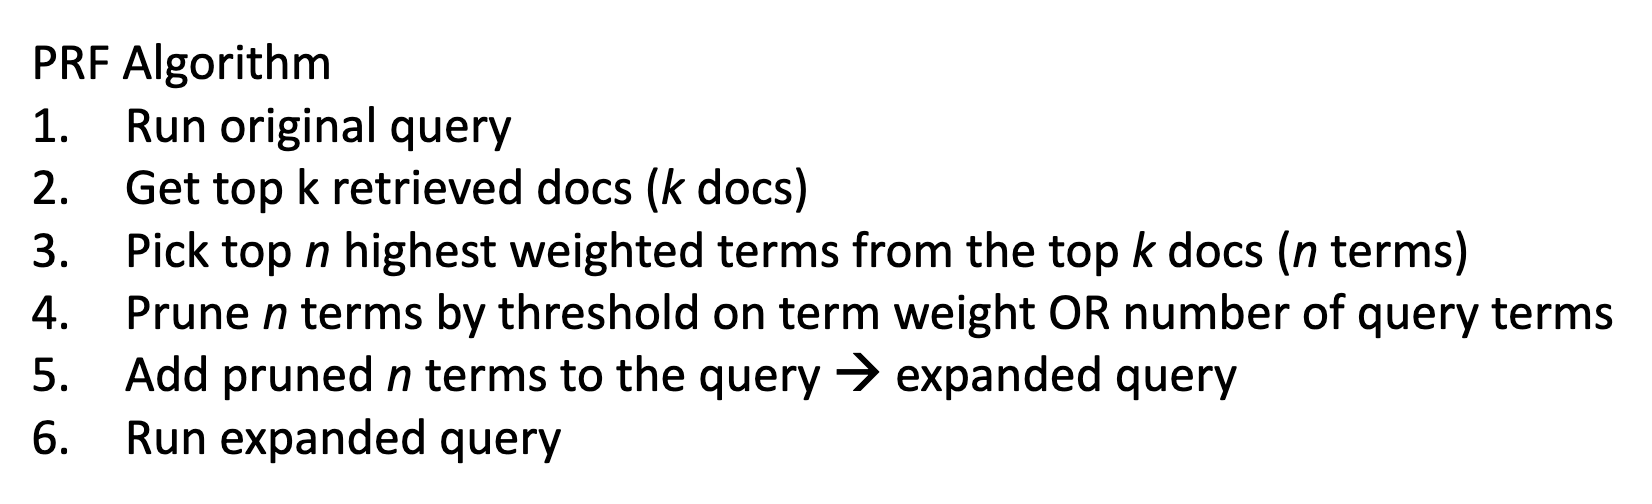

In [41]:
# Rank by BM25, then apply query rewriting with RM3, finally re-rank the documents with BM25 using rewritten queries
RM3 = pt.rewrite.RM3(index)
RM3_pipe = BM25 >> RM3 >> BM25

In [42]:
pt.Experiment(
    retr_systems=[TF, TF_IDF, BM25, SDM_BM25, RM3_pipe],
    names=['TF', 'TF-IDF', 'BM25','SDM >> BM25', 'BM25 >> RM3 >> BM25'],
    topics=topics,
    qrels=qrels,
    eval_metrics=[AP@10, nDCG@10, P@10],
    round=4,
)

,name,P@10,nDCG@10,AP@10
0,TF,0.8000,0.8510,0.3375
1,TF-IDF,0.7667,0.8408,0.3429
2,BM25,0.7667,0.8425,0.3455
3,SDM >> BM25,0.7667,0.8425,0.3455
4,BM25 >> RM3 >> BM25,0.7556,0.8392,0.3358


# Doc2Query

Doc2Query uses a Language model to:

1. Generate possible queries from the given text (doc).
2. Augment the generated query to the text.

Look at [this notebook](https://github.com/terrierteam/pyterrier_doc2query/blob/master/examples/doc2query--.ipynb) for a more concrete example. The default model used is a fine-tuned version of T5-base.

In [4]:
%%capture
!pip install pandas

In [5]:
import pandas as pd

In [1]:
!pip install --upgrade git+https://github.com/terrierteam/pyterrier_doc2query.git

import pyterrier_doc2query

  Cloning https://github.com/terrierteam/pyterrier_doc2query.git to /tmp/pip-req-build-oz2lgywn
  Running command git clone --filter=blob:none --quiet https://github.com/terrierteam/pyterrier_doc2query.git /tmp/pip-req-build-oz2lgywn
  Resolved https://github.com/terrierteam/pyterrier_doc2query.git to commit cf54da18a3bb4df2e11c18846241838771e4ecf5
  Installing build dependencies ... done
  Getting requirements to build wheel ... done
  Preparing metadata (pyproject.toml) ... done
  Preparing metadata (setup.py) ... done
  Preparing metadata (setup.py) ... done
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 208.8/208.8 kB 21.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 866.1/866.1 kB 67.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 61.3/61.3 kB 7.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.4/1.4 MB 79.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 304.8/304.8 kB 21.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━

In [2]:
Doc2Query = pyterrier_doc2query.Doc2Query(fast_tokenizer=True)

/usr/local/lib/python3.12/dist-packages/huggingface_hub/utils/_auth.py:103: UserWarning: 
Error while fetching `HF_TOKEN` secret value from your vault: 'Requesting secret HF_TOKEN timed out. Secrets can only be fetched when running from the Colab UI.'.
You are not authenticated with the Hugging Face Hub in this notebook.
If the error persists, please let us know by opening an issue on GitHub (https://github.com/huggingface/huggingface_hub/issues/new).
  warnings.warn(


tokenizer_config.json: 0.00B [00:00, ?B/s]

spiece.model:   0%|          | 0.00/792k [00:00<?, ?B/s]

special_tokens_map.json: 0.00B [00:00, ?B/s]

config.json: 0.00B [00:00, ?B/s]

model.safetensors:   0%|          | 0.00/892M [00:00<?, ?B/s]

Loading weights:   0%|          | 0/257 [00:00<?, ?it/s]

In [6]:
sample_doc = "The presence of communication amid scientific minds was equally important to the success of the Manhattan Project as scientific intellect was. The only cloud hanging over the impressive achievement of the atomic researchers and engineers is what their success truly meant; hundreds of thousands of innocent lives obliterated"
print(Doc2Query.transform(pd.DataFrame([{"docno" : "d1", "text" : sample_doc}])).loc[0, 'querygen'])

how did the manhattan project impact people
why was the manhattan project so successful
why was the manhattan project so successful


### Using Doc2Query for Indexing

#### Takes ~60 min. Use GPU, should speed up

In [7]:
def document_generate():
    for i in tqdm(range(len(docs))):
        yield {"docno": docs.iloc[i]['docno'], "text": docs.iloc[i]['text']}

doc2query = pyterrier_doc2query.Doc2Query(append=True, fast_tokenizer=True) # append generated queries to the orignal document text
iter_indexer = pt.IterDictIndexer("./indexes/doc2query", overwrite=True, meta={'docno': 20, 'text': 4096})

doc2query_indexer = doc2query >> iter_indexer
doc2query_indexer.index(document_generate())

Loading weights:   0%|          | 0/257 [00:00<?, ?it/s]

NameError: name 'pt' is not defined

In [ ]:
index_ref_doc2query = pt.IndexRef.of("./indexes/doc2query/data.properties")
index_doc2query = pt.IndexFactory.of(index_ref_doc2query)
print(index_doc2query.getCollectionStatistics().toString())

Number of documents: 2453
Number of terms: 24248
Number of postings: 214836
Number of fields: 0
Number of tokens: 298564
Field names: []
Positions:   false



In [31]:
Doc2Query_BM25 = pt.terrier.Retriever(index_doc2query, wmodel="BM25")

In [32]:
pt.Experiment(
    retr_systems=[TF, TF_IDF, BM25, SDM_BM25, RM3_pipe, Doc2Query_BM25],
    names=['TF', 'TF-IDF', 'BM25','SDM >> BM25', 'BM25 >> RM3 >> BM25','Doc2Query >> BM25'],
    topics=topics,
    qrels=qrels,
    eval_metrics=[AP@10, nDCG@10, P@10],
    round=4
)

,name,AP@10,nDCG@10,P@10
0,TF,0.3375,0.8510,0.8000
1,TF-IDF,0.3429,0.8408,0.7667
2,BM25,0.3455,0.8425,0.7667
3,SDM >> BM25,0.3455,0.8425,0.7667
4,BM25 >> RM3 >> BM25,0.3358,0.8392,0.7556
5,Doc2Query >> BM25,0.3709,0.8549,0.8000


In [33]:
new_pipeline = Doc2Query_BM25 >> RM3 >> Doc2Query_BM25

In [34]:
pt.Experiment(
    retr_systems=[TF, TF_IDF, BM25, SDM_BM25, RM3_pipe, Doc2Query_BM25, new_pipeline],
    names=['TF', 'TF-IDF', 'BM25','SDM >> BM25', 'BM25 >> RM3 >> BM25','Doc2Query >> BM25', 'Doc2Query >> BM25 >> RM3 >> Doc2Query >> BM25'],
    topics=topics,
    qrels=qrels,
    eval_metrics=[AP@10, nDCG@10, P@10],
    round=4
)

,name,AP@10,nDCG@10,P@10
0,TF,0.3375,0.8510,0.8000
1,TF-IDF,0.3429,0.8408,0.7667
2,BM25,0.3455,0.8425,0.7667
3,SDM >> BM25,0.3455,0.8425,0.7667
4,BM25 >> RM3 >> BM25,0.3358,0.8392,0.7556
5,Doc2Query >> BM25,0.3709,0.8549,0.8000
6,Doc2Query >> BM25 >> RM3 >> Doc2Query >> BM25,0.3911,0.8665,0.8111
